**LINK DE LA BASE DE DATOS:**

https://www.kaggle.com/datasets/brzy56/2024-nwsl-womens-soccer-league-player-stats-full

La **Liga Nacional de Fútbol Femenino** es la principal liga de fútbol profesional femenino del mundo con jugadores de la selección nacional de todo el mundo.

Los clubes son Angel City FC, Bay FC, Boston Legacy FC, Chicago Stars FC, Denver Summit FC, Gotham FC, Houston Dash, Kansas City Current, North Carolina Courage, Orlando Pride, Portland Thorns FC, Racing Louisville FC, San Diego Wave FC, Seattle Reign FC, Utah Royals FC y Washington Spirit.

(https://www.nwslsoccer.com/news/index)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/2026/Enero-Junio 2026/Adriana Segovia/Tercer Parcial/Base de datos/2024_nwsl_0525.csv'
df = pd.read_csv(ruta)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.columns

Index(['team', 'player_name', 'conc_player_name', 'position', 'games_played',
       'games_started', 'minutes_played', 'goals', 'accurate_pass_percentage',
       'assists', 'total_scoring_attempts', 'on_target_scoring_attempts',
       'total_attacking_assists', 'tackles', 'fouls_committed',
       'fouls_suffered', 'total_offside', 'yellow_cards', 'red_cards',
       'accurate_passes', 'total_passes', 'crosses',
       'assists_avg_over_90_mins', 'long_balls', 'successful_short_passes',
       'turnovers', 'goals_avg_over_90_mins', 'penalty_kick_goals',
       'penalty_kick_taken', 'penalty_kick_percentage',
       'accurate_shooting_percentage', 'successful_dribble',
       'dribble_percentage', 'goals_and_assists', 'tackles.1',
       'tackles_percentage', 'interceptions', 'headed_duel', 'gk_saves',
       'gk_long_ball_percentage', 'gk_total_clearance'],
      dtype='object')

Esta base de datos tiene las siguientes columnas:

    team --------------------------- Equipo
    player_name -------------------- Nombre del jugador
    conc_player_name --------------- Nombre
    position ----------------------- Posición
    games_played ------------------- Juegos jugados
    games_started ------------------ Juegos iniciados
    minutes_played ----------------- Minutos jugados
    goals -------------------------- Goles
    accurate_pass_percentage ------- Precisión de pase
    assists ------------------------ Asistencias
    total_scoring_attempts --------- Intentos totales de gol
    on_target_scoring_attempts ----- Intento o tiro a puerta
    total_attacking_assists -------- Asistencias de ataque totales
    tackles ------------------------ Entrada (defensiva)
    fouls_committed ---------------- Faltas cometidas
    fouls_suffered ----------------- Faltas sufridas (recibidas)
    total_offside ------------------ Fuera de juego
    yellow_cards ------------------- Tarjetas amarillas
    red_cards ---------------------- Tarjetas rojas
    accurate_passes ---------------- Pases precisos
    total_passes ------------------- Total de pases
    crosses ------------------------ Centros
    assists_avg_over_90_mins ------- Promedio de asistencias cada 90 minutos
    long_balls --------------------- Balones largos
    successful_short_passes -------- Pase corto exitoso
    turnovers ---------------------- Pérdida de balón
    goals_avg_over_90_mins --------- Promedio de goles por 90 minutos
    penalty_kick_goals ------------- Penal que fue gol
    penalty_kick_taken ------------- Penal ejecutado
    penalty_kick_percentage -------- Penal (efectividad)
    accurate_shooting_percentage --- Porcentaje de precisión de tiro
    successful_dribble ------------- Regato exitoso
    dribble_percentage ------------- Tasa de éxito en el regate
    goals_and_assists -------------- Goles y asistencias
    tackles_percentage ------------- Porcentaje de entrada
    interceptions ------------------ Intercepción
    headed_duel -------------------- Duelo aéreo de cabeza
    gk_saves ----------------------- Atajadas de la portera
    gk_long_ball_percentage -------- Efectividad en pases largos de la portera
    gk_total_clearance ------------- Despejes Totales de la Portera


In [ ]:
df.head()

,team,player_name,conc_player_name,position,games_played,games_started,minutes_played,goals,accurate_pass_percentage,assists,...,successful_dribble,dribble_percentage,goals_and_assists,tackles.1,tackles_percentage,interceptions,headed_duel,gk_saves,gk_long_ball_percentage,gk_total_clearance
0,Orlando Pride,Kerry Abello,KERRYABELLO,DEFENDER,11,11.0,927,0,81,1,...,12,52,1,13,45,10,5,NaN,NaN,NaN
1,Seattle Reign,Emeri Adames,EMERIADAMES,FORWARD,11,3.0,273,1,75,0,...,3,20,1,3,60,3,7,NaN,NaN,NaN
2,Orlando Pride,Adriana,ADRIANA,FORWARD,9,7.0,641,1,76,1,...,11,41,2,2,50,5,4,NaN,NaN,NaN
3,San Diego Wave FC,Amirah Ali,AMIRAHALI,FORWARD,5,1.0,114,0,63,0,...,1,33,0,2,67,1,2,NaN,NaN,NaN
4,Orlando Pride,Amanda Allen,AMANDAALLEN,FORWARD,7,NaN,81,0,70,1,...,3,60,1,3,60,0,0,NaN,NaN,NaN


**Variable objetivo:** position

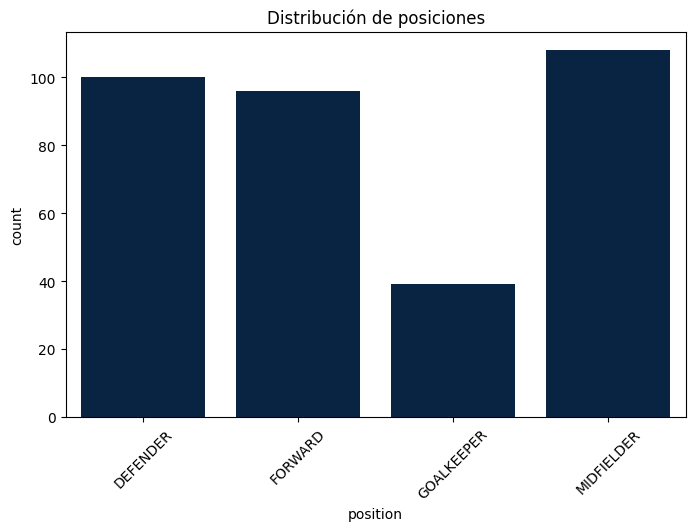

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='position', data=df, color='#00234c')

plt.title('Distribución de posiciones')
plt.xticks(rotation=45)

# Guardar imagen
#plt.savefig('distribucion_posiciones.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
tabla = df['position'].value_counts()
tabla

,count
position,
MIDFIELDER,108
DEFENDER,100
FORWARD,96
GOALKEEPER,39


**MIDFIELDER** = Centrocampista.

**DEFENDER** = Defensa.

**FORWARD** = Delantera.

**GOALKEEPER** = Portera.

In [ ]:
df = df.iloc[:-1]

In [ ]:
df.isnull().sum()

,0
team,0
player_name,0
conc_player_name,0
position,0
games_played,0
games_started,83
minutes_played,0
goals,0
accurate_pass_percentage,0
assists,0


In [ ]:
# Eliminar columnas irrelevantes
df = df.drop(['player_name', 'team', 'conc_player_name','penalty_kick_percentage', 'penalty_kick_taken', 'penalty_kick_goals', 'games_started'], axis=1, errors='ignore')

# Eliminar duplicado de tackles
df = df.loc[:, ~df.columns.duplicated()]

# Eliminar variables de porteras
df = df.drop(['gk_saves', 'gk_long_ball_percentage', 'gk_total_clearance'], axis=1, errors='ignore')

# Verificar
df.head()

,position,games_played,minutes_played,goals,accurate_pass_percentage,assists,total_scoring_attempts,on_target_scoring_attempts,total_attacking_assists,tackles,...,turnovers,goals_avg_over_90_mins,accurate_shooting_percentage,successful_dribble,dribble_percentage,goals_and_assists,tackles.1,tackles_percentage,interceptions,headed_duel
0,DEFENDER,11,927,0,81,1,5,3,1,13,...,171,0.00,60,12,52,1,13,45,10,5
1,FORWARD,11,273,1,75,0,8,2,0,3,...,64,0.33,25,3,20,1,3,60,3,7
2,FORWARD,9,641,1,76,1,14,7,1,2,...,122,0.14,50,11,41,2,2,50,5,4
3,FORWARD,5,114,0,63,0,3,2,0,2,...,34,0.00,67,1,33,0,2,67,1,2
4,FORWARD,7,81,0,70,1,0,0,1,3,...,25,0.00,0,3,60,1,3,60,0,0


In [ ]:
df.isnull().sum()

,0
position,0
games_played,0
minutes_played,0
goals,0
accurate_pass_percentage,0
assists,0
total_scoring_attempts,0
on_target_scoring_attempts,0
total_attacking_assists,0
tackles,0


In [ ]:
df = df[df['minutes_played'] > 0]

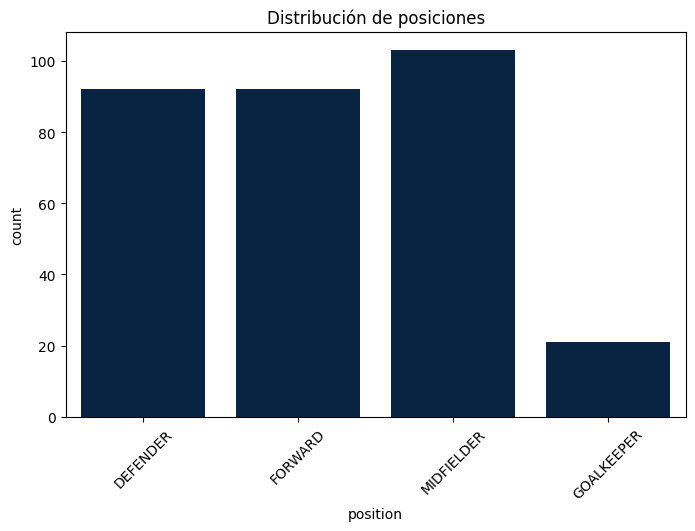

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='position', data=df, color='#00234c')

plt.title('Distribución de posiciones')
plt.xticks(rotation=45)

plt.show()

In [ ]:
tabla = df['position'].value_counts()
tabla

,count
position,
MIDFIELDER,103
DEFENDER,92
FORWARD,92
GOALKEEPER,21


In [ ]:
df.shape

(308, 31)

In [ ]:
print(df.describe())

       games_played  minutes_played       goals  accurate_pass_percentage  \
count    308.000000      308.000000  308.000000                308.000000   
mean       7.457792      481.847403    0.652597                 74.759740   
std        3.320282      324.557779    1.234451                 11.686488   
min        1.000000        1.000000    0.000000                  0.000000   
25%        5.000000      197.250000    0.000000                 69.750000   
50%        8.000000      483.000000    0.000000                 76.000000   
75%       10.000000      772.500000    1.000000                 81.250000   
max       20.000000     1530.000000    8.000000                100.000000   

          assists  total_scoring_attempts  on_target_scoring_attempts  \
count  308.000000              308.000000                  308.000000   
mean     0.435065                4.538961                    2.266234   
std      0.944211                5.888357                    3.444378   
min      0.000

#**DELANTERAS (FORWARD)**


**Prueba t-test**

Se utilizó la prueba t de muestras independientes debido a que permite comparar las medias entre dos grupos (delanteras y otras posiciones) y determinar si las diferencias observadas son estadísticamente significativas.

In [ ]:
df_del = df[df["position"] == "FORWARD"]
df_no_del = df[df["position"] != "FORWARD"]

diferencias = df_del.mean(numeric_only=True) - df_no_del.mean(numeric_only=True)

In [ ]:
from scipy.stats import ttest_ind
resultados = {}

for col in df.select_dtypes(include="number").columns:
    stat, p = ttest_ind(df_del[col], df_no_del[col], nan_policy='omit')
    resultados[col] = p

p_values = pd.Series(resultados).sort_values()
print(p_values)

total_offside                   6.031956e-23
on_target_scoring_attempts      2.684985e-19
total_scoring_attempts          4.063547e-19
goals_avg_over_90_mins          3.798681e-18
goals                           1.150347e-16
goals_and_assists               1.699879e-12
long_balls                      3.169027e-09
successful_dribble              4.023105e-09
accurate_passes                 2.678050e-08
accurate_shooting_percentage    2.987199e-08
successful_short_passes         6.971244e-08
total_passes                    1.681015e-07
accurate_pass_percentage        2.983297e-06
interceptions                   6.190257e-04
total_attacking_assists         1.475748e-03
assists                         1.475748e-03
headed_duel                     1.232024e-02
fouls_suffered                  2.447331e-02
tackles_percentage              8.106491e-02
tackles.1                       9.688069e-02
tackles                         9.688069e-02
yellow_cards                    1.222536e-01
crosses   

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
significativas = p_values[p_values < 0.05]
print(significativas)

total_offside                   6.031956e-23
on_target_scoring_attempts      2.684985e-19
total_scoring_attempts          4.063547e-19
goals_avg_over_90_mins          3.798681e-18
goals                           1.150347e-16
goals_and_assists               1.699879e-12
long_balls                      3.169027e-09
successful_dribble              4.023105e-09
accurate_passes                 2.678050e-08
accurate_shooting_percentage    2.987199e-08
successful_short_passes         6.971244e-08
total_passes                    1.681015e-07
accurate_pass_percentage        2.983297e-06
interceptions                   6.190257e-04
total_attacking_assists         1.475748e-03
assists                         1.475748e-03
headed_duel                     1.232024e-02
fouls_suffered                  2.447331e-02
dtype: float64




La prueba t de muestras independientes permitió identificar variables con diferencias estadísticamente significativas entre delanteras y otras posiciones. Destacan principalmente variables ofensivas como goles, tiros totales y tiros a portería, las cuales presentan valores p extremadamente bajos, indicando una fuerte evidencia de diferencia. Asimismo, variables relacionadas con la distribución del balón, como pases, también resultaron significativas, aunque en sentido negativo, lo que refleja una menor participación de las delanteras en la construcción del juego. Finalmente, variables como el fuera de lugar y las faltas recibidas se interpretan como consecuencias del rol ofensivo


**Diferencia de medias**

La diferencia de medias permite cuantificar la magnitud de las diferencias entre delanteras y otras posiciones, complementando el análisis de significancia estadística obtenido mediante la prueba t.

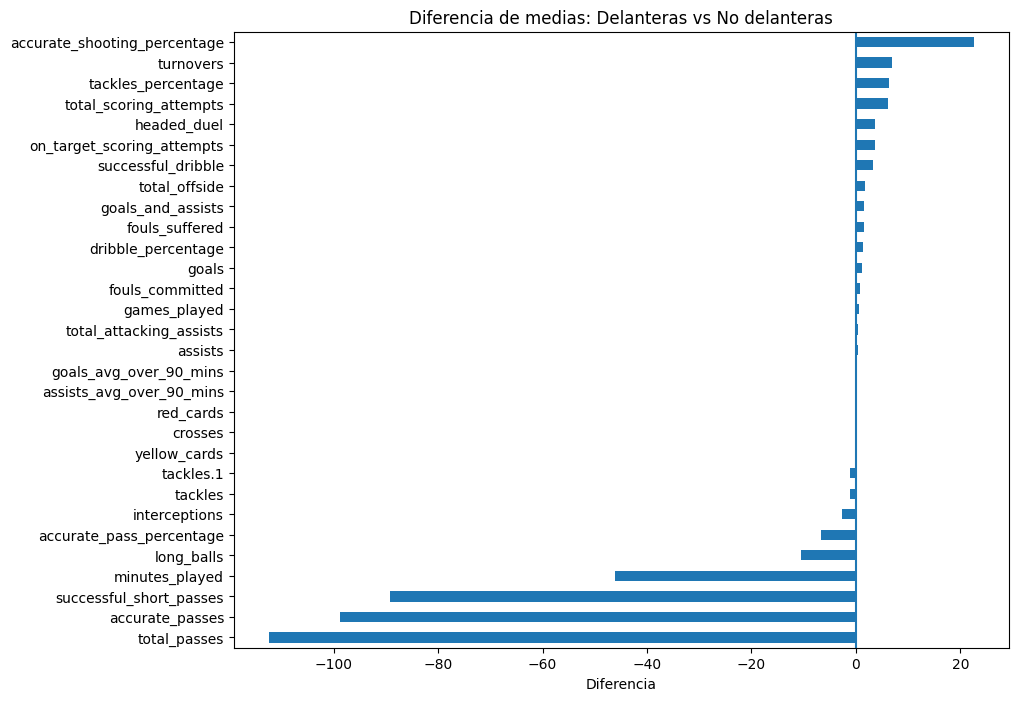

In [ ]:
plt.figure(figsize=(10, 8))

diferencias.sort_values().plot(kind="barh")

plt.title("Diferencia de medias: Delanteras vs No delanteras")
plt.xlabel("Diferencia")

plt.axvline(0)

# Guardar imagen
plt.savefig('diferencia_medias_delanteras.png', bbox_inches='tight')

plt.show()

In [ ]:
print(diferencias.sort_values())

total_passes                   -112.379227
accurate_passes                 -98.748994
successful_short_passes         -89.141908
minutes_played                  -46.078502
long_balls                      -10.513285
accurate_pass_percentage         -6.694042
interceptions                    -2.594203
tackles                          -1.209944
tackles.1                        -1.209944
yellow_cards                     -0.189211
crosses                          -0.021739
red_cards                         0.003221
assists_avg_over_90_mins          0.023931
goals_avg_over_90_mins            0.265642
assists                           0.371578
total_attacking_assists           0.371578
games_played                      0.525161
fouls_committed                   0.700886
goals                             1.208333
dribble_percentage                1.347021
fouls_suffered                    1.566023
goals_and_assists                 1.579911
total_offside                     1.799919
successful_

Las más altas:

goals                             1.208333

dribble_percentage                1.347021

fouls_suffered                    1.566023

goals_and_assists                 1.579911

total_offside                     1.799919

successful_dribble                3.197464

on_target_scoring_attempts        3.619163

headed_duel                       3.716586

total_scoring_attempts            6.159622

tackles_percentage                6.403180

turnovers                         6.981683

accurate_shooting_percentage     22.553543

_______________________________________________________________
**(VARIABLES IMPORTANTES A INTERPRETAR POR EL SIGNIFICADO) Enfocar mayor atención**


**accurate_shooting_percentage** (+22.55)

**total_scoring_attempts** (+6.15)

**on_target_scoring_attempts** (+3.61)

**successful_dribble** (+3.19)

**goals_and_assists** (+1.57)

**goals** (+1.20)

___________________________________________________________________
El análisis de diferencia de medias y pruebas estadísticas muestra que las delanteras se caracterizan principalmente por variables ofensivas como tiros totales, tiros a portería, goles y porcentaje de efectividad en el disparo, las cuales presentan las mayores diferencias respecto a otras posiciones. Asimismo, destacan en acciones individuales como el regate y en su contribución directa a la generación de goles.

En contraste, variables relacionadas con la distribución del balón, como pases totales y pases precisos, presentan valores significativamente menores, lo que indica una baja participación en la construcción del juego. Esto refuerza el rol de la delantera como finalizadora de las jugadas más que como generadora de posesión.

Por otro lado, variables como pérdidas de balón, faltas y fuera de lugar muestran valores elevados; sin embargo, estas no se interpretan como habilidades, sino como consecuencias del estilo de juego ofensivo, caracterizado por un mayor riesgo en la toma de decisiones

Una variable en duda es headed_duel ¿Define o no a una Delantera?
___________________________________________________________________



**Boxplot de algunas variables**

Los boxplots permiten visualizar la distribución de las variables entre posiciones, evidenciando diferencias en mediana, dispersión y presencia de valores atípicos, lo que complementa el análisis estadístico.

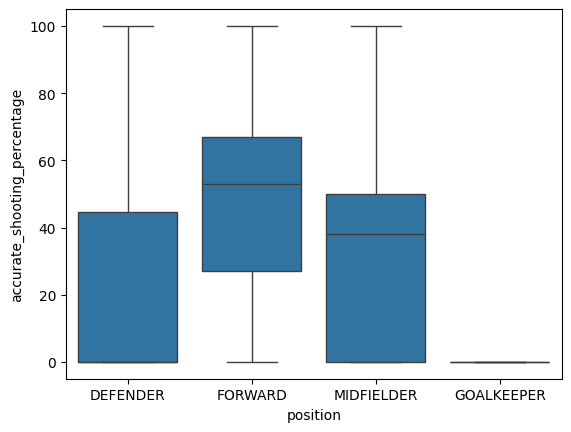

In [ ]:
sns.boxplot(x="position", y="accurate_shooting_percentage", data=df)
plt.savefig('accurate_shooting_percentage_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

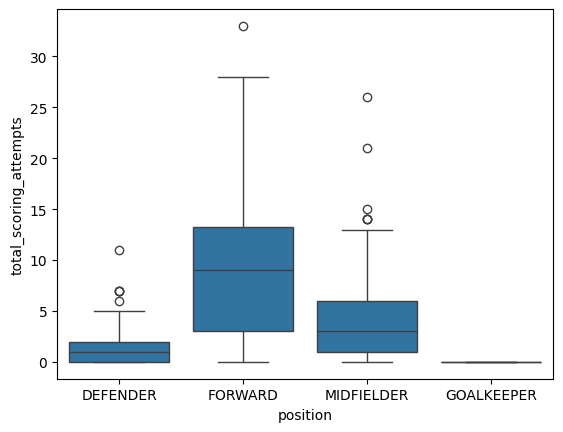

In [ ]:
sns.boxplot(x="position", y="total_scoring_attempts", data=df)
plt.savefig('total_scoring_attempts_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

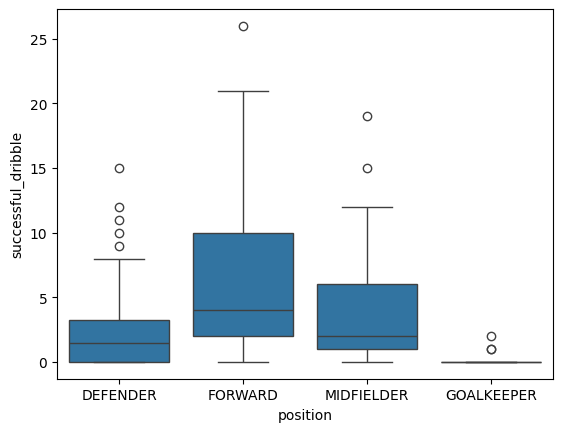

In [ ]:
sns.boxplot(x="position", y="successful_dribble", data=df)
plt.savefig('successful_dribble_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

<Axes: xlabel='position', ylabel='goals'>

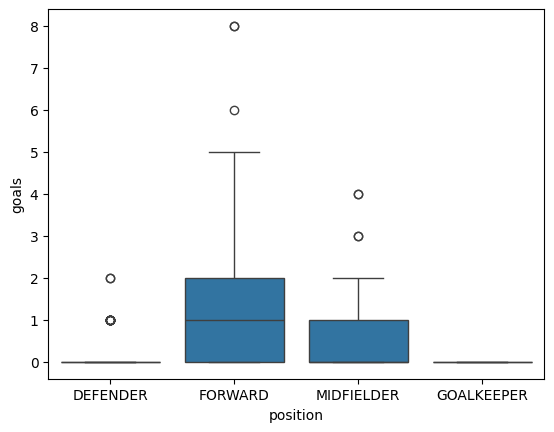

In [ ]:
sns.boxplot(x="position", y="goals", data=df)

#**CENTROCAMPISTA (MIDFIELDER)**

**Prueba t-test**

In [ ]:
df_del = df[df["position"] == "MIDFIELDER"]
df_no_del = df[df["position"] != "MIDFIELDER"]

diferencias = df_del.mean(numeric_only=True) - df_no_del.mean(numeric_only=True)

In [ ]:
from scipy.stats import ttest_ind
resultados = {}

for col in df.select_dtypes(include="number").columns:
    stat, p = ttest_ind(df_del[col], df_no_del[col], nan_policy='omit')
    resultados[col] = p

p_values = pd.Series(resultados).sort_values()
print(p_values)

tackles                         0.000340
tackles.1                       0.000340
fouls_committed                 0.002877
total_offside                   0.003579
yellow_cards                    0.004997
long_balls                      0.005338
fouls_suffered                  0.018544
goals_avg_over_90_mins          0.021732
goals                           0.037698
minutes_played                  0.071028
red_cards                       0.080000
tackles_percentage              0.130806
total_passes                    0.234857
accurate_passes                 0.235369
turnovers                       0.245597
assists_avg_over_90_mins        0.248904
on_target_scoring_attempts      0.256256
goals_and_assists               0.300649
dribble_percentage              0.329566
interceptions                   0.335403
successful_short_passes         0.340323
headed_duel                     0.361638
accurate_pass_percentage        0.422586
crosses                         0.479327
total_scoring_at

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
significativas = p_values[p_values < 0.05]
print(significativas)

tackles                   0.000340
tackles.1                 0.000340
fouls_committed           0.002877
total_offside             0.003579
yellow_cards              0.004997
long_balls                0.005338
fouls_suffered            0.018544
goals_avg_over_90_mins    0.021732
goals                     0.037698
dtype: float64


El análisis muestra que las centrocampistas se caracterizan principalmente por su participación en tareas defensivas y de recuperación de balón, destacando variables como tackles. Asimismo, presentan una alta interacción física en el juego, reflejada en faltas cometidas, faltas recibidas y tarjetas amarillas. Además, contribuyen a la distribución del balón mediante acciones como pases largos. Aunque también presentan diferencias en variables ofensivas como goles, estas no constituyen su principal característica, lo que confirma su rol como enlace entre defensa y ataque

**Diferencia de medias**

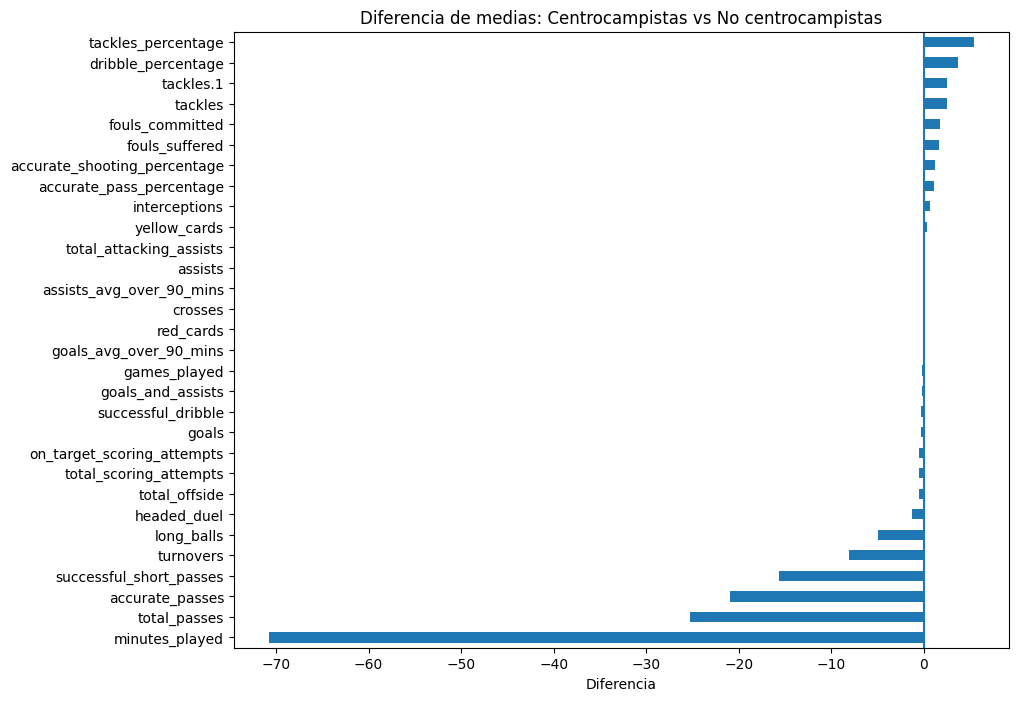

In [ ]:
plt.figure(figsize=(10, 8))

diferencias.sort_values().plot(kind="barh")

plt.title("Diferencia de medias: Centrocampistas vs No centrocampistas")
plt.xlabel("Diferencia")

plt.axvline(0)
plt.savefig('DIFCentro.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
print(diferencias.sort_values())

minutes_played                 -70.750036
total_passes                   -25.283164
accurate_passes                -20.936491
successful_short_passes        -15.646886
turnovers                       -8.085390
long_balls                      -4.904665
headed_duel                     -1.320009
total_offside                   -0.553445
total_scoring_attempts          -0.474260
on_target_scoring_attempts      -0.472934
goals                           -0.309496
successful_dribble              -0.261331
goals_and_assists               -0.233815
games_played                    -0.191854
goals_avg_over_90_mins          -0.072036
red_cards                       -0.029268
crosses                          0.009756
assists_avg_over_90_mins         0.052780
assists                          0.075681
total_attacking_assists          0.075681
yellow_cards                     0.331944
interceptions                    0.714468
accurate_pass_percentage         1.134075
accurate_shooting_percentage     1

Las mas altas:

tackles 2.512148

tackles.1 2.512148

dribble_percentage 3.645371

tackles_percentage 5.383377

fouls_committed 1.763533

fouls_suffered 1.589486

interceptions 0.714468

accurate_pass_percentage 1.134075

accurate_shooting_percentage 1.191949

yellow_cards 0.331944


__________________________________________________________________
**(VARIABLES IMPORTANTES A INTERPRETAR POR EL SIGNIFICADO) Enfocar mayor atención**

**tackles** (+2.51)

**tackles_percentage** (+5.38)

**interceptions** (+0.71)

**fouls_committed** (+1.76)

**fouls_suffered** (+1.58)

**dribble_percentage** (+3.64)

**accurate_pass_percentage** (+1.13)

_____________________________________________________________________

El análisis de diferencia de medias muestra que las centrocampistas se caracterizan principalmente por una mayor participación en tareas defensivas, destacando variables como tackles, porcentaje de tackles e intercepciones, las cuales presentan los valores más altos respecto a otras posiciones. Asimismo, presentan una alta interacción física en el juego, reflejada en el número de faltas cometidas y recibidas.

Por otro lado, también destacan en aspectos técnicos como el control y la eficiencia, evidenciado en el porcentaje de regate y la precisión en los pases, lo que sugiere un estilo de juego más controlado.

En contraste, variables ofensivas como goles, tiros totales y tiros a portería presentan valores negativos, lo que indica que las centrocampistas no se enfocan en la finalización de jugadas. Esto refuerza su rol como jugadoras de equilibrio dentro del equipo, participando tanto en la recuperación del balón como en la organización del juego.

______________________________________________________________________

**Boxplot**

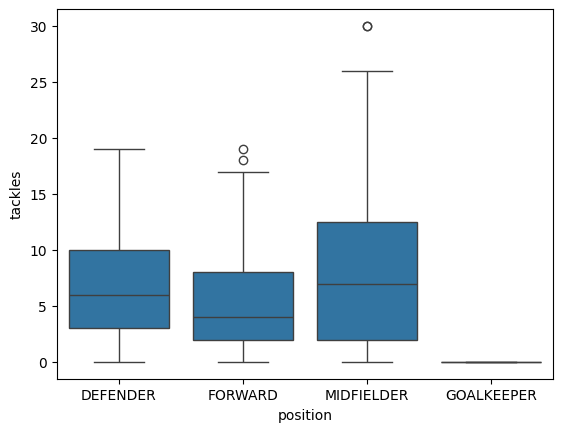

In [ ]:
sns.boxplot(x="position", y="tackles", data=df)
plt.savefig('tackles_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

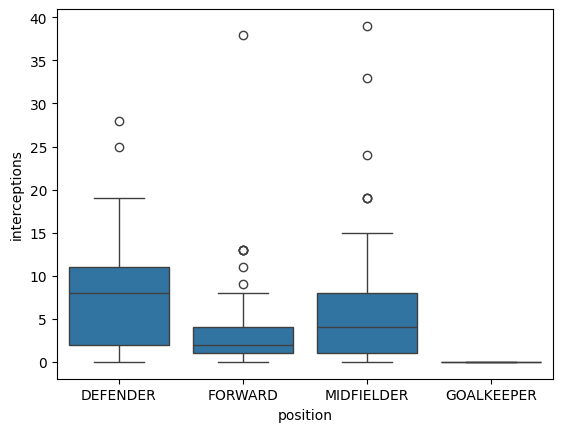

In [ ]:
sns.boxplot(x="position", y="interceptions", data=df)
plt.savefig('interceptions_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

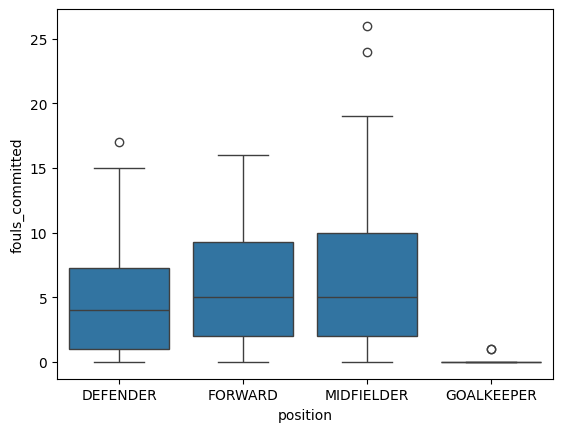

In [ ]:
sns.boxplot(x="position", y="fouls_committed", data=df)
plt.savefig('fouls_committed_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

<Axes: xlabel='position', ylabel='accurate_pass_percentage'>

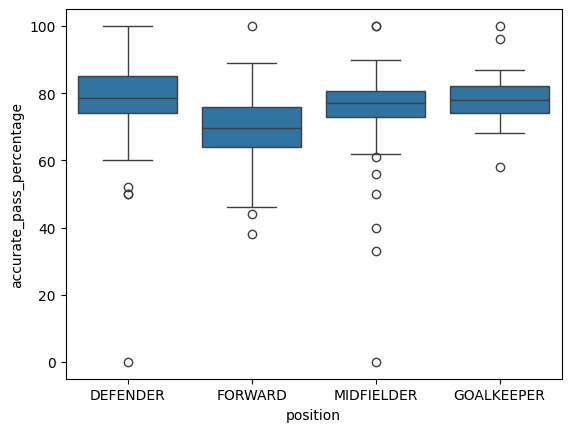

In [ ]:
sns.boxplot(x="position", y="accurate_pass_percentage", data=df)

“Aunque los boxplot no muestra una separación visual marcada entre grupos, la prueba t confirma que las diferencias son estadísticamente significativas, lo que indica que estas pueden no ser evidentes a simple vista debido a la variabilidad de los datos.

**DEFENSA (DEFENDER)**

**Prueba t-test**

In [ ]:
df_del = df[df["position"] == "DEFENDER"]
df_no_del = df[df["position"] != "DEFENDER"]

diferencias = df_del.mean(numeric_only=True) - df_no_del.mean(numeric_only=True)

In [ ]:
from scipy.stats import ttest_ind
resultados = {}

for col in df.select_dtypes(include="number").columns:
    stat, p = ttest_ind(df_del[col], df_no_del[col], nan_policy='omit')
    resultados[col] = p

p_values = pd.Series(resultados).sort_values()
print(p_values)

successful_short_passes         9.056530e-11
accurate_passes                 2.198489e-10
total_passes                    2.809413e-09
total_scoring_attempts          5.048728e-09
on_target_scoring_attempts      1.337193e-08
total_offside                   1.074111e-06
goals_avg_over_90_mins          3.383069e-06
interceptions                   3.651324e-06
goals                           1.089182e-05
goals_and_assists               2.077991e-05
long_balls                      1.084723e-03
successful_dribble              1.478238e-03
accurate_shooting_percentage    1.514250e-03
accurate_pass_percentage        4.126498e-03
fouls_suffered                  7.979767e-03
total_attacking_assists         8.069568e-03
assists                         8.069568e-03
minutes_played                  7.620106e-02
tackles_percentage              1.192439e-01
fouls_committed                 1.513110e-01
turnovers                       2.666789e-01
red_cards                       2.781017e-01
assists_av

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
significativas = p_values[p_values < 0.05]
print(significativas)

successful_short_passes         9.056530e-11
accurate_passes                 2.198489e-10
total_passes                    2.809413e-09
total_scoring_attempts          5.048728e-09
on_target_scoring_attempts      1.337193e-08
total_offside                   1.074111e-06
goals_avg_over_90_mins          3.383069e-06
interceptions                   3.651324e-06
goals                           1.089182e-05
goals_and_assists               2.077991e-05
long_balls                      1.084723e-03
successful_dribble              1.478238e-03
accurate_shooting_percentage    1.514250e-03
accurate_pass_percentage        4.126498e-03
fouls_suffered                  7.979767e-03
total_attacking_assists         8.069568e-03
assists                         8.069568e-03
dtype: float64


Las defensas se caracterizan por una alta participación en la distribución del balón, destacando en pases totales y pases precisos, así como en acciones defensivas como intercepciones. En contraste, presentan valores significativamente menores en variables ofensivas como goles y tiros, lo que confirma su rol centrado en la contención y el inicio del juego desde zonas defensivas.

**Diferencia de medias**

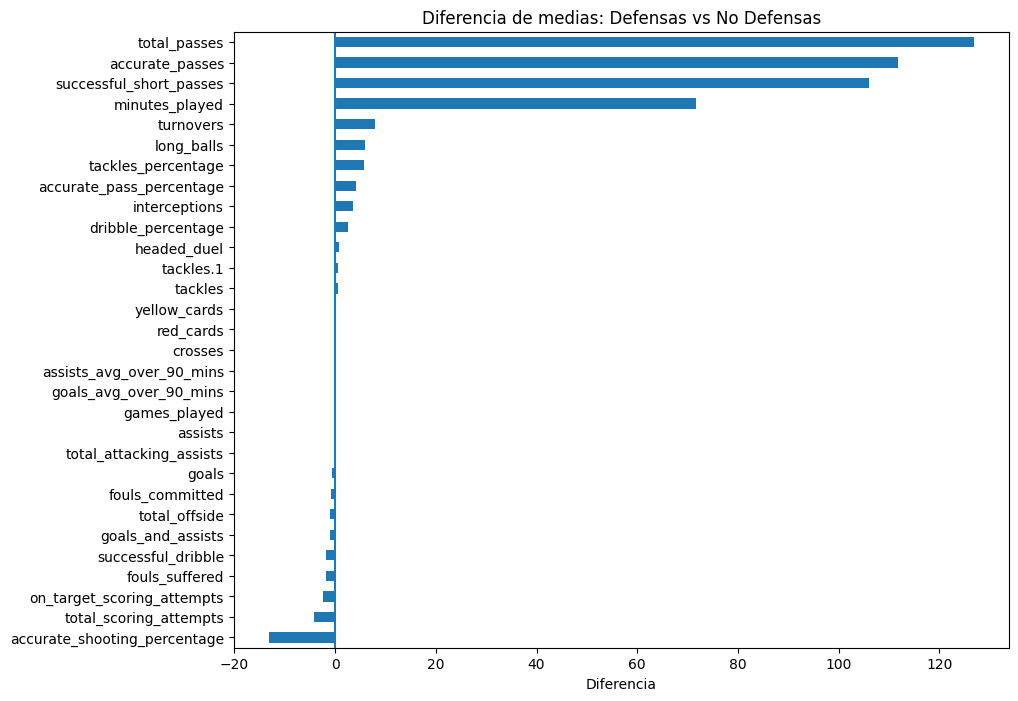

In [ ]:
plt.figure(figsize=(10, 8))

diferencias.sort_values().plot(kind="barh")

plt.title("Diferencia de medias: Defensas vs No Defensas")
plt.xlabel("Diferencia")

plt.axvline(0)
plt.savefig('DIFDefensa.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print(diferencias.sort_values())

accurate_shooting_percentage    -13.125604
total_scoring_attempts           -4.178341
on_target_scoring_attempts       -2.379026
fouls_suffered                   -1.843800
successful_dribble               -1.762279
goals_and_assists                -0.977456
total_offside                    -0.943438
fouls_committed                  -0.880032
goals                            -0.667069
total_attacking_assists          -0.310386
assists                          -0.310386
games_played                     -0.234300
goals_avg_over_90_mins           -0.148341
assists_avg_over_90_mins         -0.049070
crosses                           0.009259
red_cards                         0.018720
yellow_cards                      0.027778
tackles                           0.603462
tackles.1                         0.603462
headed_duel                       0.833736
dribble_percentage                2.586957
interceptions                     3.481481
accurate_pass_percentage          4.155395
tackles_per

Las más altas:

accurate_passes 111.854066

total_passes 126.835346

successful_short_passes 106.054952

minutes_played 71.637882

long_balls 5.915862

tackles_percentage 5.721216

accurate_pass_percentage 4.155395

interceptions 3.481481

dribble_percentage 2.586957

headed_duel 0.833736

tackles 0.603462

__________________________________________________________________
**(VARIABLES IMPORTANTES A INTERPRETAR POR EL SIGNIFICADO) Enfocar mayor atención**

**total_passes** (+126.83)

**accurate_passes** (+111.85)

**successful_short_passes** (+106.05)

**minutes_played** (+71.63)

**tackles_percentage** (+5.72)

**long_balls** (+5.91)

**accurate_pass_percentage** (+4.15)

**interceptions** (+3.48)

____________________________________________________________________
El análisis de diferencia de medias muestra que las defensas se caracterizan principalmente por una alta participación en la distribución del balón, destacando variables como pases totales, pases precisos y pases cortos exitosos, las cuales presentan las mayores diferencias respecto a otras posiciones. Esto sugiere que las defensas cumplen un rol importante en la salida de balón y en la construcción inicial del juego desde zonas bajas.

Asimismo, destacan en acciones defensivas como intercepciones y porcentaje de tackles, lo que confirma su función principal de recuperación y contención del rival. También presentan valores relevantes en balones largos, lo que indica su participación en cambios de juego o despejes estratégicos.

En contraste, variables ofensivas como goles, tiros a portería y efectividad de disparo presentan valores negativos, lo que refuerza su bajo involucramiento en la finalización de jugadas.

En conjunto, estos resultados confirman que las defensas no solo cumplen una función de contención, sino que también son clave en la organización y salida del juego desde la línea defensiva.

_____________________________________________________________________



**Boxplot**

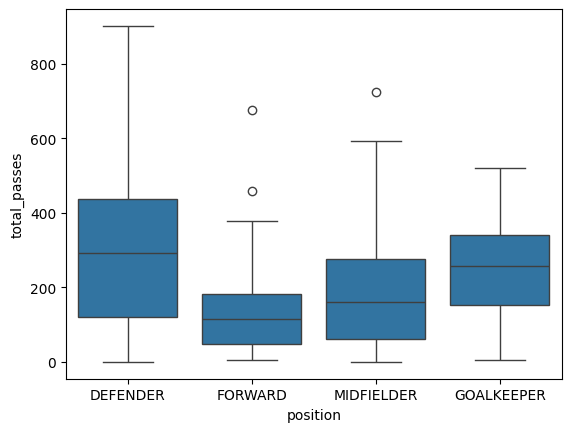

In [ ]:
sns.boxplot(x="position", y="total_passes", data=df)
plt.savefig('total_passes_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

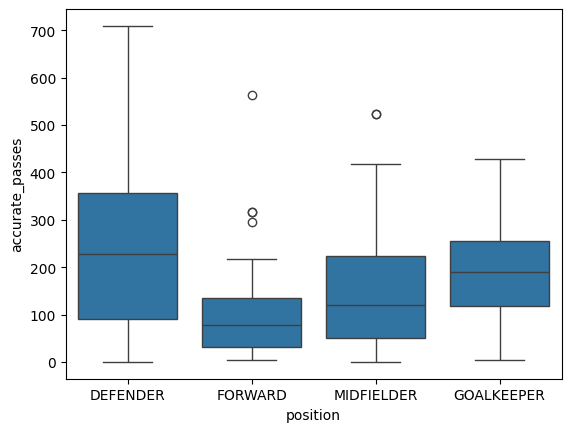

In [ ]:
sns.boxplot(x="position", y="accurate_passes", data=df)
plt.savefig('accurate_passes_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

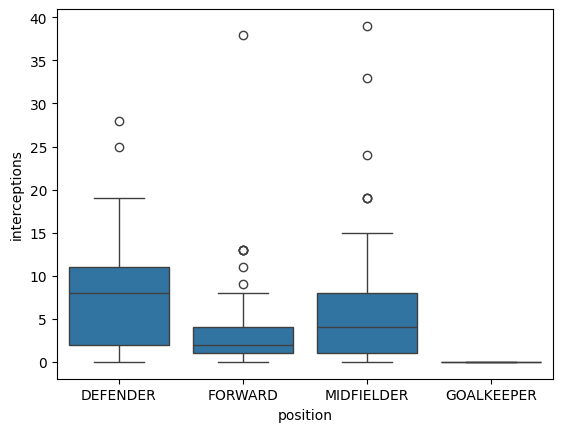

In [ ]:
sns.boxplot(x="position", y="interceptions", data=df)
plt.savefig('interceptions_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

<Axes: xlabel='position', ylabel='long_balls'>

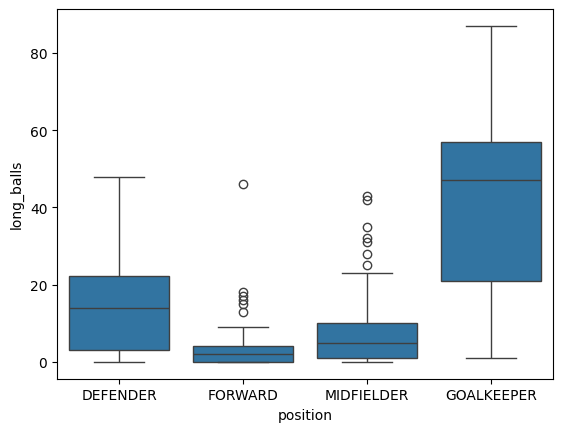

In [ ]:
sns.boxplot(x="position", y="long_balls", data=df)

**Porteras (GOALKEEPER)**

In [ ]:
df_del = df[df["position"] == "GOALKEEPER"]
df_no_del = df[df["position"] != "GOALKEEPER"]

diferencias = df_del.mean(numeric_only=True) - df_no_del.mean(numeric_only=True)

In [ ]:
from scipy.stats import ttest_ind
resultados = {}

for col in df.select_dtypes(include="number").columns:
    stat, p = ttest_ind(df_del[col], df_no_del[col], nan_policy='omit')
    resultados[col] = p

p_values = pd.Series(resultados).sort_values()
print(p_values)

long_balls                      1.334315e-26
tackles_percentage              3.136284e-21
tackles                         1.573982e-07
tackles.1                       1.573982e-07
fouls_committed                 3.107462e-07
accurate_shooting_percentage    2.133988e-06
interceptions                   7.571902e-05
headed_duel                     1.059084e-04
successful_dribble              1.418617e-04
dribble_percentage              2.014624e-04
fouls_suffered                  2.097601e-04
total_scoring_attempts          2.231902e-04
on_target_scoring_attempts      1.683531e-03
yellow_cards                    4.371537e-03
goals_and_assists               5.510020e-03
goals                           1.185217e-02
total_offside                   1.299034e-02
goals_avg_over_90_mins          2.216988e-02
minutes_played                  2.552696e-02
assists                         2.847847e-02
total_attacking_assists         2.847847e-02
accurate_pass_percentage        9.608502e-02
turnovers 

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
significativas = p_values[p_values < 0.05]
print(significativas)

long_balls                      1.334315e-26
tackles_percentage              3.136284e-21
tackles                         1.573982e-07
tackles.1                       1.573982e-07
fouls_committed                 3.107462e-07
accurate_shooting_percentage    2.133988e-06
interceptions                   7.571902e-05
headed_duel                     1.059084e-04
successful_dribble              1.418617e-04
dribble_percentage              2.014624e-04
fouls_suffered                  2.097601e-04
total_scoring_attempts          2.231902e-04
on_target_scoring_attempts      1.683531e-03
yellow_cards                    4.371537e-03
goals_and_assists               5.510020e-03
goals                           1.185217e-02
total_offside                   1.299034e-02
goals_avg_over_90_mins          2.216988e-02
minutes_played                  2.552696e-02
assists                         2.847847e-02
total_attacking_assists         2.847847e-02
dtype: float64


El análisis de la prueba t muestra que las porteras se diferencian principalmente por su participación en acciones de salida de balón, destacando la variable de balones largos como la más significativa. Asimismo, presentan valores significativamente distintos en casi todas las variables de campo, lo que se explica por su rol altamente especializado.

En contraste, variables ofensivas como goles, asistencias y tiros presentan diferencias importantes, lo cual no refleja participación activa, sino su ausencia en este tipo de acciones. En conjunto, estos resultados confirman el rol exclusivo de las porteras como última línea defensiva y su limitada participación en acciones ofensivas o de campo

**Diferencia de medias**

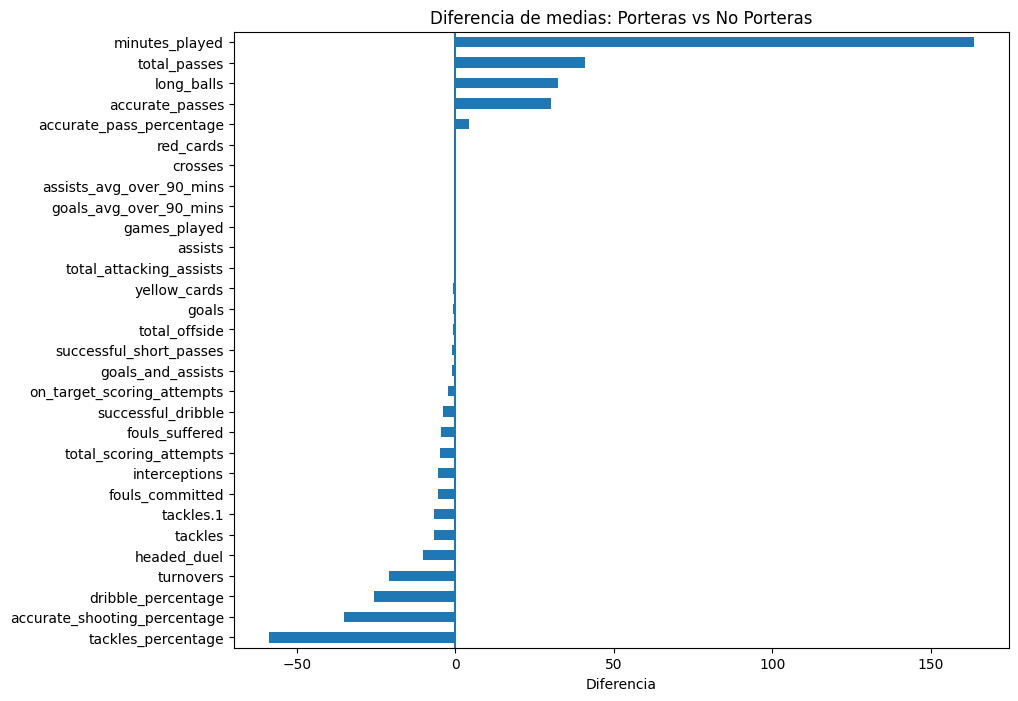

In [ ]:
plt.figure(figsize=(10, 8))

diferencias.sort_values().plot(kind="barh")

plt.title("Diferencia de medias: Porteras vs No Porteras")
plt.xlabel("Diferencia")

plt.axvline(0)
plt.savefig('DIFPortero.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print(diferencias.sort_values())

tackles_percentage              -58.836237
accurate_shooting_percentage    -35.261324
dribble_percentage              -25.742160
turnovers                       -20.983740
headed_duel                     -10.378630
tackles                          -6.801394
tackles.1                        -6.801394
fouls_committed                  -5.587689
interceptions                    -5.428571
total_scoring_attempts           -4.871080
fouls_suffered                   -4.652729
successful_dribble               -3.816492
on_target_scoring_attempts       -2.432056
goals_and_assists                -1.167247
successful_short_passes          -0.947735
total_offside                    -0.885017
goals                            -0.700348
yellow_cards                     -0.630662
total_attacking_assists          -0.466899
assists                          -0.466899
games_played                     -0.286876
goals_avg_over_90_mins           -0.134390
assists_avg_over_90_mins         -0.102021
crosses    

Las más altas:

minutes_played 163.592334

total_passes 40.912892

accurate_passes 30.139373

long_balls 32.341463

accurate_pass_percentage 4.397213

tackles_percentage 0.000000 (o cercano a 0 dependiendo del redondeo)

interceptions -5.428571

tackles -6.801394

dribble_percentage -25.742160

accurate_shooting_percentage -35.261324
____________________________________________________________________

**(VARIABLES IMPORTANTES A INTERPRETAR POR EL SIGNIFICADO) Enfocar mayor atención**

**minutes_played** (+163.59)

**total_passes** (+40.91)

**accurate_passes** (+30.13)

**long_balls** (+32.34)

**accurate_pass_percentage** (+4.39)
____________________________________________________________________

El análisis de diferencia de medias muestra que las porteras se caracterizan principalmente por una alta participación en variables relacionadas con la distribución del balón, destacando los pases totales, pases precisos y balones largos como las diferencias más importantes respecto a las demás posiciones. Esto refleja su papel fundamental en la reanudación del juego desde el área y en la salida de balón como primera fase de construcción.

Asimismo, destaca la variable de minutos jugados, lo cual sugiere una participación constante en el campo dentro de su rol específico, ya que las porteras suelen tener menor rotación en comparación con los jugadores de campo.

En contraste, la mayoría de las variables ofensivas y defensivas de campo presentan valores negativos, lo que no indica un bajo rendimiento, sino su ausencia natural en este tipo de acciones debido a su posición altamente especializada.

En conjunto, estos resultados confirman que las porteras cumplen un rol completamente diferenciado dentro del equipo, centrado en la organización defensiva, la distribución del balón y la iniciación del juego desde el área.

**Boxplot**

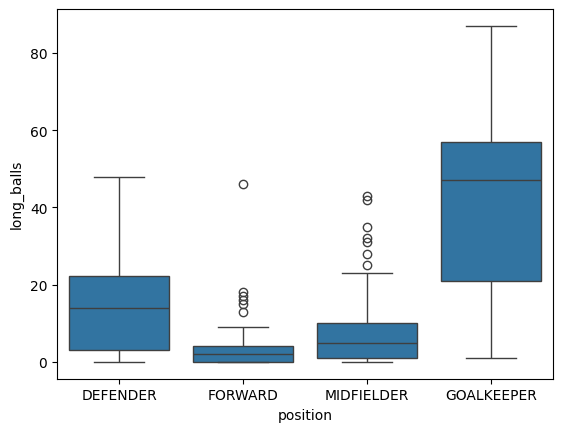

In [ ]:
sns.boxplot(x="position", y="long_balls", data=df)
plt.savefig('long_balls_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

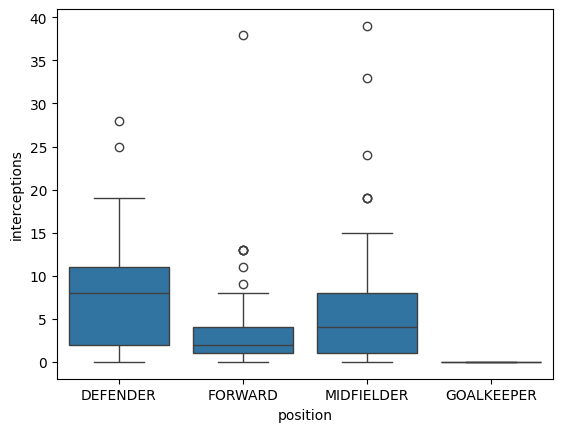

In [ ]:
sns.boxplot(x="position", y="interceptions", data=df)
plt.show()

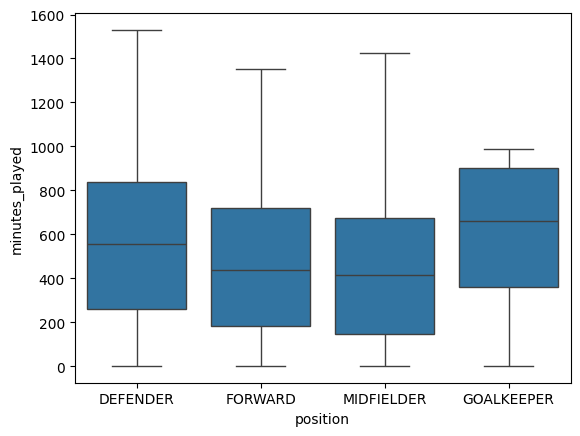

In [ ]:
sns.boxplot(x="position", y="minutes_played", data=df)
plt.savefig('minutes_played_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

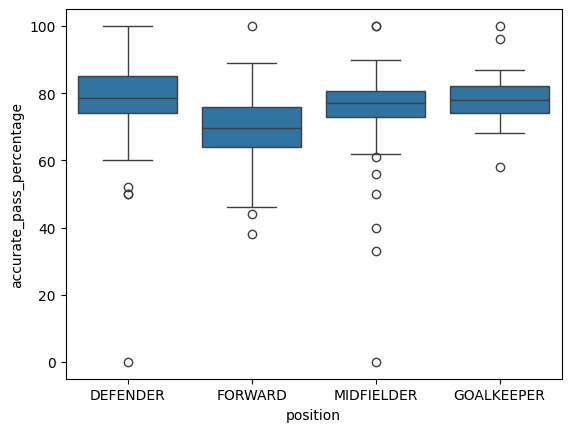

In [ ]:
sns.boxplot(x="position", y="accurate_pass_percentage", data=df)
plt.show()

**CONCLUSIÓN:**

El análisis estadístico permitió identificar diferencias significativas entre posiciones mediante pruebas t, diferencias de medias y visualización con boxplots. Estos resultados muestran que cada posición dentro del fútbol femenino presenta patrones estadísticos distintivos asociados a su rol táctico.

Las delanteras se caracterizan por métricas ofensivas como goles y tiros; las centrocampistas por acciones de recuperación y equilibrio en el juego; las defensas por su participación en la salida de balón y recuperación; y las porteras por variables específicas relacionadas con la distribución y su rol limitado en acciones de campo.

En conjunto, el análisis permitió identificar y describir los perfiles de cada posición, lo cual constituye una base sólida para futuros modelos de clasificación supervisada que permitan predecir la posición de una jugadora a partir de sus estadísticas.

## Preprocesamiento de datos para KNN

Antes de aplicar KNN, es crucial preparar los datos:

1.  **Separar características (X) y variable objetivo (y):** Identificamos qué columnas serán las características de entrada y cuál será la variable que queremos predecir (`position`).
2.  **Codificación de la variable objetivo:** Como `position` es una variable categórica, la convertiremos a formato numérico usando `LabelEncoder`.
3.  **Escalado de características:** KNN es sensible a la escala de las características. Por lo tanto, escalaremos todas las características numéricas para que tengan una media de 0 y una desviación estándar de 1 usando `StandardScaler`.

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Separar características (X) y variable objetivo (y)
X = df.drop('position', axis=1)
y = df['position']

display(X.head())
display(y.head())

,games_played,minutes_played,goals,accurate_pass_percentage,assists,total_scoring_attempts,on_target_scoring_attempts,total_attacking_assists,tackles,fouls_committed,...,turnovers,goals_avg_over_90_mins,accurate_shooting_percentage,successful_dribble,dribble_percentage,goals_and_assists,tackles.1,tackles_percentage,interceptions,headed_duel
0,11,927,0,81,1,5,3,1,13,9,...,171,0.00,60,12,52,1,13,45,10,5
1,11,273,1,75,0,8,2,0,3,3,...,64,0.33,25,3,20,1,3,60,3,7
2,9,641,1,76,1,14,7,1,2,1,...,122,0.14,50,11,41,2,2,50,5,4
3,5,114,0,63,0,3,2,0,2,3,...,34,0.00,67,1,33,0,2,67,1,2
4,7,81,0,70,1,0,0,1,3,1,...,25,0.00,0,3,60,1,3,60,0,0


,position
0,DEFENDER
1,FORWARD
2,FORWARD
3,FORWARD
4,FORWARD


### Codificación de la variable objetivo

In [ ]:
# Inicializar y aplicar LabelEncoder a la variable objetivo 'y'
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Valores originales de 'position':", le.inverse_transform([0, 1, 2, 3]))
print("Valores codificados de 'position':")
display(pd.Series(y_encoded).value_counts())

Valores originales de 'position': ['DEFENDER' 'FORWARD' 'GOALKEEPER' 'MIDFIELDER']
Valores codificados de 'position':


,count
3,103
0,92
1,92
2,21


### Escalado de las características numéricas

In [ ]:
# Identificar columnas numéricas para escalar
# Excluir cualquier columna que no sea numérica y que pudiera haberse mantenido por error
numerical_cols = X.select_dtypes(include=np.number).columns

# Inicializar y aplicar StandardScaler a las características numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[numerical_cols])

# Convertir el array escalado de nuevo a un DataFrame con los nombres de las columnas originales
X_scaled_df = pd.DataFrame(X_scaled, columns=numerical_cols, index=X.index)

display(X_scaled_df.head())

,games_played,minutes_played,goals,accurate_pass_percentage,assists,total_scoring_attempts,on_target_scoring_attempts,total_attacking_assists,tackles,fouls_committed,...,turnovers,goals_avg_over_90_mins,accurate_shooting_percentage,successful_dribble,dribble_percentage,goals_and_assists,tackles.1,tackles_percentage,interceptions,headed_duel
0,1.068576,1.373799,-0.529514,0.534841,0.599288,0.078424,0.213380,0.599288,1.140141,0.752477,...,1.637177,-0.481747,0.813239,1.845745,0.444890,-0.047018,1.140141,-0.333769,0.807339,-0.542749
1,1.068576,-0.644530,0.281881,0.020592,-0.461521,0.588733,-0.077421,-0.461521,-0.571182,-0.468399,...,-0.224168,0.787756,-0.235411,-0.167003,-0.592205,-0.047018,-0.571182,0.175819,-0.336303,-0.375247
2,0.465237,0.491166,0.281881,0.106300,0.599288,1.609351,1.376582,0.599288,-0.742314,-0.875358,...,0.784785,0.056830,0.513625,1.622106,0.088389,0.489340,-0.742314,-0.163907,-0.009548,-0.626500
3,-0.741441,-1.135225,-0.529514,-1.007906,-0.461521,-0.261782,-0.077421,-0.461521,-0.742314,-0.468399,...,-0.746040,-0.481747,1.022969,-0.614280,-0.170885,-0.583377,-0.742314,0.413627,-0.663058,-0.794002
4,-0.138102,-1.237067,-0.529514,-0.407949,0.599288,-0.772091,-0.659022,0.599288,-0.571182,-0.875358,...,-0.902602,-0.481747,-0.984447,-0.167003,0.704164,-0.047018,-0.571182,0.175819,-0.826436,-0.961503


### Evaluación del modelo con K-Fold Cross-Validation

Para obtener una evaluación más robusta del modelo, utilizaremos K-Fold Cross-Validation. Esto dividirá los datos en 'k' pliegues, entrenando el modelo 'k' veces, usando cada pliegue como conjunto de prueba una vez y los demás como entrenamiento. Esto ayuda a reducir la varianza en la estimación del rendimiento del modelo.

--- Evaluación del Modelo KNN con K-Fold Cross-Validation ---

----- Fold 1/5 -----
Precisión (Accuracy) del Fold 1: 0.5484

----- Fold 2/5 -----
Precisión (Accuracy) del Fold 2: 0.6452

----- Fold 3/5 -----
Precisión (Accuracy) del Fold 3: 0.5968

----- Fold 4/5 -----
Precisión (Accuracy) del Fold 4: 0.5246

----- Fold 5/5 -----
Precisión (Accuracy) del Fold 5: 0.5902

--- Resultados Promedio de K-Fold Cross-Validation ---
Precisión (Accuracy) promedio: 0.5810 (+/- 0.0417)

Informe de Clasificación Promedio:

              precision    recall  f1-score   support
DEFENDER    0.53      0.64      0.58      18
FORWARD     0.70      0.63      0.66      18
GOALKEEPER  0.80      0.62      0.69      4
MIDFIELDER  0.48      0.45      0.46      20

accuracy                             0.58        308
macro avg       0.63      0.59      0.60        308
weighted avg    0.60      0.58      0.58        308

Matriz de Confusión Promedio (o del último Fold como ejemplo):



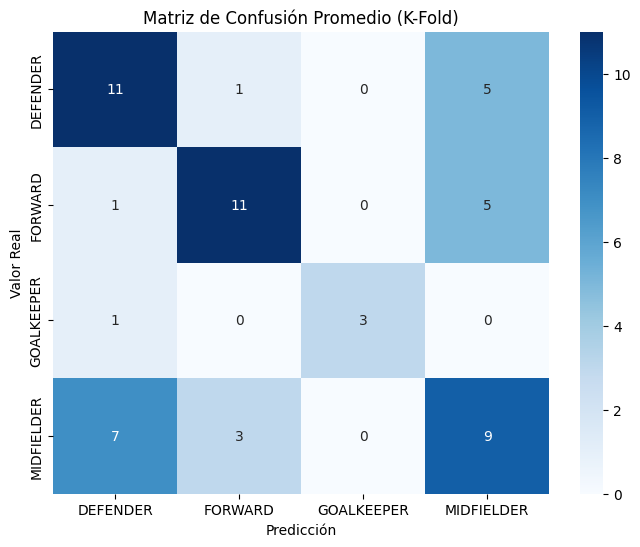

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier # Importar KNeighborsClassifier
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Definir el número de folds (k)
# Un valor común es 5 o 10
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Listas para almacenar las métricas de cada fold
accuracy_scores = []
classification_reports = []
confusion_matrices = []

# Inicializar el modelo KNN con el mismo n_neighbors que antes
knn_kf = KNeighborsClassifier(n_neighbors=7)

print("--- Evaluación del Modelo KNN con K-Fold Cross-Validation ---")

for fold, (train_index, test_index) in enumerate(kf.split(X_scaled_df, y_encoded)):
    print(f"\n----- Fold {fold+1}/{kf.n_splits} -----")

    # Dividir los datos para el fold actual
    X_train_fold, X_test_fold = X_scaled_df.iloc[train_index], X_scaled_df.iloc[test_index]
    y_train_fold, y_test_fold = y_encoded[train_index], y_encoded[test_index]

    # Entrenar el modelo
    knn_kf.fit(X_train_fold, y_train_fold)

    # Realizar predicciones
    y_pred_fold = knn_kf.predict(X_test_fold)

    # Calcular métricas
    acc = accuracy_score(y_test_fold, y_pred_fold)
    accuracy_scores.append(acc)

    report = classification_report(y_test_fold, y_pred_fold, target_names=le.classes_, output_dict=True)
    classification_reports.append(report)

    cm = confusion_matrix(y_test_fold, y_pred_fold)
    confusion_matrices.append(cm)

    print(f"Precisión (Accuracy) del Fold {fold+1}: {acc:.4f}")
    # print(f"Informe de Clasificación del Fold {fold+1}:\n{classification_report(y_test_fold, y_pred_fold, target_names=le.classes_)}")

# Calcular el promedio de las métricas
print("\n--- Resultados Promedio de K-Fold Cross-Validation ---")
print(f"Precisión (Accuracy) promedio: {np.mean(accuracy_scores):.4f} (+/- {np.std(accuracy_scores):.4f})\n")

# Para el informe de clasificación y la matriz de confusión, podemos promediar o mostrar uno representativo.
# Aquí, mostraremos el informe de clasificación promedio y la matriz de confusión del último fold.

# Calculamos el promedio del classification_report
avg_report = {}
for class_name in le.classes_:
    avg_report[class_name] = {
        'precision': np.mean([r[class_name]['precision'] for r in classification_reports if class_name in r]),
        'recall': np.mean([r[class_name]['recall'] for r in classification_reports if class_name in r]),
        'f1-score': np.mean([r[class_name]['f1-score'] for r in classification_reports if class_name in r]),
        'support': np.sum([r[class_name]['support'] for r in classification_reports if class_name in r]) / kf.n_splits # Sum supports and average, as support is per fold
    }
macro_avg_precision = np.mean([r['macro avg']['precision'] for r in classification_reports])
macro_avg_recall = np.mean([r['macro avg']['recall'] for r in classification_reports])
macro_avg_f1 = np.mean([r['macro avg']['f1-score'] for r in classification_reports])

weighted_avg_precision = np.mean([r['weighted avg']['precision'] for r in classification_reports])
weighted_avg_recall = np.mean([r['weighted avg']['recall'] for r in classification_reports])
weighted_avg_f1 = np.mean([r['weighted avg']['f1-score'] for r in classification_reports])

print("Informe de Clasificación Promedio:\n")
print(f"              precision    recall  f1-score   support")
for class_name, metrics in avg_report.items():
    print(f"{class_name:<10}  {metrics['precision']:.2f}      {metrics['recall']:.2f}      {metrics['f1-score']:.2f}      {int(metrics['support'])}")
print(f"\n{'accuracy':<10}                           {np.mean(accuracy_scores):.2f}        {len(y_encoded)}") # Total samples for accuracy
print(f"macro avg       {macro_avg_precision:.2f}      {macro_avg_recall:.2f}      {macro_avg_f1:.2f}        {len(y_encoded)}")
print(f"weighted avg    {weighted_avg_precision:.2f}      {weighted_avg_recall:.2f}      {weighted_avg_f1:.2f}        {len(y_encoded)}")


print("\nMatriz de Confusión Promedio (o del último Fold como ejemplo):\n")
# Para una matriz de confusión promedio, sumamos todas las matrices y las dividimos por k.
avg_cm = np.mean(confusion_matrices, axis=0).astype(int)
plt.figure(figsize=(8, 6))
sns.heatmap(avg_cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión Promedio (K-Fold)')
plt.show()

## Resultados del Modelo K-Nearest Neighbors (KNN)

El modelo KNN fue evaluado utilizando K-Fold Cross-Validation (con k=5) para obtener una estimación más robusta de su rendimiento. A continuación, se resumen los resultados clave:

### Precisión (Accuracy)

La precisión (accuracy) promedio del modelo KNN fue de **0.5810**, con una desviación estándar de +/- 0.0417. Esto indica que el modelo clasifica correctamente la posición de los jugadores aproximadamente el 58.10% de las veces, con una variabilidad moderada entre los diferentes folds de la validación cruzada.

### Informe de Clasificación Promedio

El informe de clasificación promedio proporciona una visión más detallada del rendimiento del modelo para cada clase (posición):

- **DEFENDER (Defensa):** El modelo mostró una precisión de 0.53 y un recall de 0.64. Esto significa que cuando predice que un jugador es defensa, acierta el 53% de las veces, y es capaz de identificar correctamente al 64% de los defensas reales.
- **FORWARD (Delantera):** Para las delanteras, la precisión fue de 0.70 y el recall de 0.63. Es la clase con mayor precisión promedio, indicando que el modelo es relativamente bueno cuando clasifica a un jugador como delantera.
- **GOALKEEPER (Portera):** Las porteras obtuvieron una alta precisión de 0.80 y un recall de 0.62. A pesar de ser una clase minoritaria, el modelo tiende a ser preciso cuando identifica a una portera.
- **MIDFIELDER (Centrocampista):** Las centrocampistas tuvieron la precisión más baja con 0.48 y un recall de 0.45, lo que sugiere que el modelo tiene más dificultades para distinguir correctamente a las centrocampistas de otras posiciones.

El **macro avg F1-score** fue de 0.60 y el **weighted avg F1-score** fue de 0.58, lo que refleja un rendimiento general moderado, con un desempeño desigual entre las clases.

### Matriz de Confusión Promedio

La matriz de confusión promedio (mostrada en el gráfico anterior) visualiza la cantidad de aciertos y errores para cada clase. Se observa que:

- Existe una tendencia a confundir a las `MIDFIELDER` con otras posiciones, especialmente con `DEFENDER` y `FORWARD`, lo que se alinea con el bajo recall y precisión para esta clase.
- Las `GOALKEEPER` son relativamente bien clasificadas, aunque con un menor número de muestras.
- `FORWARD` muestra un buen balance entre predicciones correctas y capacidad de identificar a los jugadores de esa posición.

En conclusión, el modelo KNN proporciona una base para la clasificación de posiciones, destacando en la identificación de `FORWARD` y `GOALKEEPER`. Sin embargo, tiene limitaciones con `MIDFIELDER`, lo que sugiere que podría ser necesario explorar otros modelos o técnicas de mejora para esta clase.

## Implementación del modelo KNN

Ahora que los datos están preprocesados, podemos:

1.  Inicializar el modelo `KNeighborsClassifier`.
2.  Entrenar el modelo con los datos de entrenamiento.
3.  Realizar predicciones sobre el conjunto de prueba.
4.  Evaluar el rendimiento del modelo utilizando `accuracy_score`, `classification_report` y `confusion_matrix`.

--- Evaluación del Modelo KNN ---
Precisión (Accuracy): 0.5484

Informe de Clasificación:

              precision    recall  f1-score   support

    DEFENDER       0.48      0.53      0.50        19
     FORWARD       0.75      0.56      0.64        16
  GOALKEEPER       1.00      0.75      0.86         8
  MIDFIELDER       0.39      0.47      0.43        19

    accuracy                           0.55        62
   macro avg       0.65      0.58      0.61        62
weighted avg       0.59      0.55      0.56        62

Matriz de Confusión:



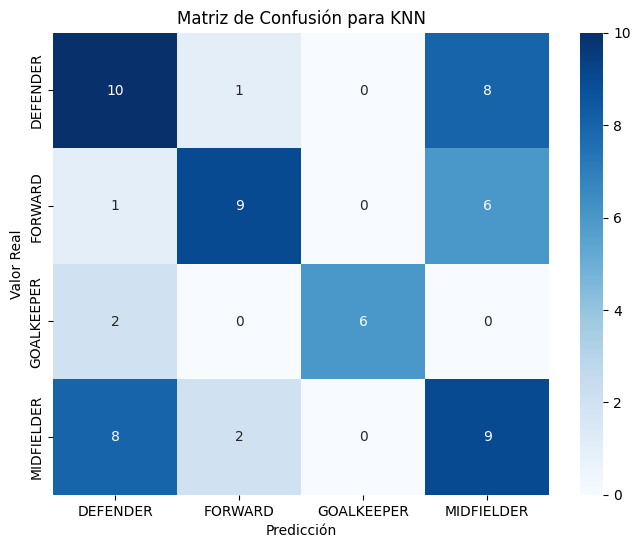

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
from sklearn.model_selection import train_test_split # Import train_test_split

# Dividir los datos en conjuntos de entrenamiento y prueba
# Usar los datos escalados X_scaled_df y los labels codificados y_encoded
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y_encoded, test_size=0.2, random_state=42)

# 1. Inicializar el modelo KNN (puedes ajustar el número de vecinos 'n_neighbors')
knn = KNeighborsClassifier(n_neighbors=7) # n_neighbors es un hiperparámetro importante

# 2. Entrenar el modelo con los datos de entrenamiento
knn.fit(X_train, y_train)

# 3. Realizar predicciones sobre el conjunto de prueba
y_pred = knn.predict(X_test)

# 4. Evaluar el rendimiento del modelo
print("--- Evaluación del Modelo KNN ---")
print(f"Precisión (Accuracy): {accuracy_score(y_test, y_pred):.4f}\n")

print("Informe de Clasificación:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("Matriz de Confusión:\n")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión para KNN')
plt.savefig('Matriz_de_confusion_KNN.png', dpi=300, bbox_inches='tight')
plt.show()

## Implementación del modelo de Regresión Logística

Vamos a probar con otro clasificador, la Regresión Logística, para ver cómo se compara su rendimiento con el de KNN. Seguiremos los mismos pasos:

1.  Inicializar el modelo `LogisticRegression`.
2.  Entrenar el modelo con los datos de entrenamiento.
3.  Realizar predicciones sobre el conjunto de prueba.
4.  Evaluar el rendimiento del modelo utilizando `accuracy_score`, `classification_report` y `confusion_matrix`.

--- Evaluación del Modelo de Regresión Logística ---
Precisión (Accuracy): 0.7419

Informe de Clasificación:

              precision    recall  f1-score   support

    DEFENDER       0.67      0.84      0.74        19
     FORWARD       0.92      0.69      0.79        16
  GOALKEEPER       1.00      0.75      0.86         8
  MIDFIELDER       0.65      0.68      0.67        19

    accuracy                           0.74        62
   macro avg       0.81      0.74      0.76        62
weighted avg       0.77      0.74      0.75        62

Matriz de Confusión:



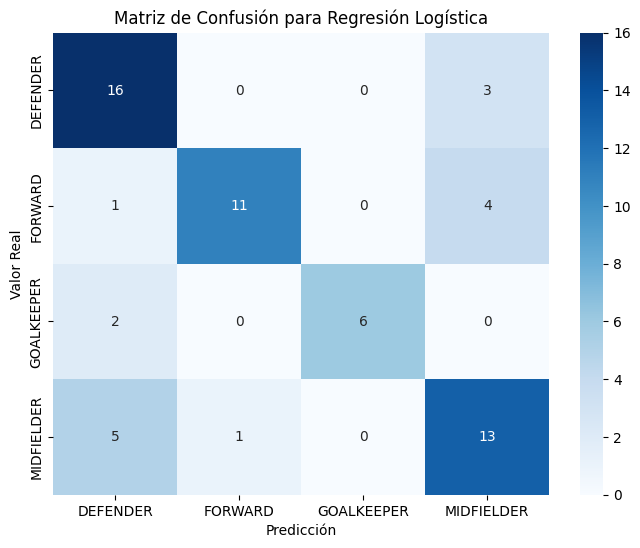

In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. Inicializar el modelo de Regresión Logística
# Es buena práctica aumentar max_iter para asegurar la convergencia
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# 2. Entrenar el modelo con los datos de entrenamiento
log_reg.fit(X_train, y_train)

# 3. Realizar predicciones sobre el conjunto de prueba
y_pred_log_reg = log_reg.predict(X_test)

# 4. Evaluar el rendimiento del modelo
print("--- Evaluación del Modelo de Regresión Logística ---")
print(f"Precisión (Accuracy): {accuracy_score(y_test, y_pred_log_reg):.4f}\n")

print("Informe de Clasificación:\n")
print(classification_report(y_test, y_pred_log_reg, target_names=le.classes_))

print("Matriz de Confusión:\n")
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión para Regresión Logística')
plt.show()

### Evaluación del Modelo de Regresión Logística con K-Fold Cross-Validation

Ahora evaluaremos la Regresión Logística usando K-Fold Cross-Validation para obtener una estimación más robusta de su rendimiento.

--- Evaluación del Modelo de Regresión Logística con K-Fold Cross-Validation ---

----- Fold 1/5 -----
Precisión (Accuracy) del Fold 1: 0.7419

----- Fold 2/5 -----
Precisión (Accuracy) del Fold 2: 0.6613

----- Fold 3/5 -----
Precisión (Accuracy) del Fold 3: 0.6935

----- Fold 4/5 -----
Precisión (Accuracy) del Fold 4: 0.7049

----- Fold 5/5 -----
Precisión (Accuracy) del Fold 5: 0.6393

--- Resultados Promedio de K-Fold Cross-Validation (Regresión Logística) ---
Precisión (Accuracy) promedio: 0.6882 (+/- 0.0355)

Informe de Clasificación Promedio:

              precision    recall  f1-score   support
DEFENDER    0.66      0.66      0.65      18
FORWARD     0.82      0.72      0.76      18
GOALKEEPER  0.87      0.90      0.84      4
MIDFIELDER  0.59      0.65      0.61      20

accuracy                             0.69        308
macro avg       0.73      0.73      0.72        308
weighted avg    0.71      0.69      0.69        308

Matriz de Confusión Promedio (K-Fold Regresión Logí

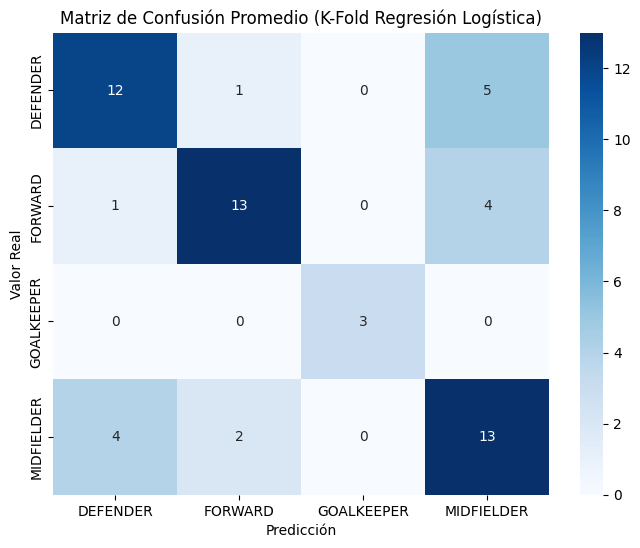

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Definir el número de folds (k)
kf_log_reg = KFold(n_splits=5, shuffle=True, random_state=42)

# Listas para almacenar las métricas de cada fold
accuracy_scores_lr = []
classification_reports_lr = []
confusion_matrices_lr = []

# Inicializar el modelo de Regresión Logística
log_reg_kf = LogisticRegression(max_iter=1000, random_state=42)

print("--- Evaluación del Modelo de Regresión Logística con K-Fold Cross-Validation ---")

for fold, (train_index, test_index) in enumerate(kf_log_reg.split(X_scaled_df, y_encoded)):
    print(f"\n----- Fold {fold+1}/{kf_log_reg.n_splits} -----")

    # Dividir los datos para el fold actual
    X_train_fold, X_test_fold = X_scaled_df.iloc[train_index], X_scaled_df.iloc[test_index]
    y_train_fold, y_test_fold = y_encoded[train_index], y_encoded[test_index]

    # Entrenar el modelo
    log_reg_kf.fit(X_train_fold, y_train_fold)

    # Realizar predicciones
    y_pred_fold = log_reg_kf.predict(X_test_fold)

    # Calcular métricas
    acc = accuracy_score(y_test_fold, y_pred_fold)
    accuracy_scores_lr.append(acc)

    report = classification_report(y_test_fold, y_pred_fold, target_names=le.classes_, output_dict=True)
    classification_reports_lr.append(report)

    cm = confusion_matrix(y_test_fold, y_pred_fold)
    confusion_matrices_lr.append(cm)

    print(f"Precisión (Accuracy) del Fold {fold+1}: {acc:.4f}")

# Calcular el promedio de las métricas
print("\n--- Resultados Promedio de K-Fold Cross-Validation (Regresión Logística) ---")
print(f"Precisión (Accuracy) promedio: {np.mean(accuracy_scores_lr):.4f} (+/- {np.std(accuracy_scores_lr):.4f})\n")

# Calculamos el promedio del classification_report
avg_report_lr = {}
for class_name in le.classes_:
    avg_report_lr[class_name] = {
        'precision': np.mean([r[class_name]['precision'] for r in classification_reports_lr if class_name in r]),
        'recall': np.mean([r[class_name]['recall'] for r in classification_reports_lr if class_name in r]),
        'f1-score': np.mean([r[class_name]['f1-score'] for r in classification_reports_lr if class_name in r]),
        'support': np.sum([r[class_name]['support'] for r in classification_reports_lr if class_name in r]) / kf_log_reg.n_splits
    }
macro_avg_precision_lr = np.mean([r['macro avg']['precision'] for r in classification_reports_lr])
macro_avg_recall_lr = np.mean([r['macro avg']['recall'] for r in classification_reports_lr])
macro_avg_f1_lr = np.mean([r['macro avg']['f1-score'] for r in classification_reports_lr])

weighted_avg_precision_lr = np.mean([r['weighted avg']['precision'] for r in classification_reports_lr])
weighted_avg_recall_lr = np.mean([r['weighted avg']['recall'] for r in classification_reports_lr])
weighted_avg_f1_lr = np.mean([r['weighted avg']['f1-score'] for r in classification_reports_lr])

print("Informe de Clasificación Promedio:\n")
print(f"              precision    recall  f1-score   support")
for class_name, metrics in avg_report_lr.items():
    print(f"{class_name:<10}  {metrics['precision']:.2f}      {metrics['recall']:.2f}      {metrics['f1-score']:.2f}      {int(metrics['support'])}")
print(f"\n{'accuracy':<10}                           {np.mean(accuracy_scores_lr):.2f}        {len(y_encoded)}")
print(f"macro avg       {macro_avg_precision_lr:.2f}      {macro_avg_recall_lr:.2f}      {macro_avg_f1_lr:.2f}        {len(y_encoded)}")
print(f"weighted avg    {weighted_avg_precision_lr:.2f}      {weighted_avg_recall_lr:.2f}      {weighted_avg_f1_lr:.2f}        {len(y_encoded)}")


print("\nMatriz de Confusión Promedio (K-Fold Regresión Logística):\n")
avg_cm_lr = np.mean(confusion_matrices_lr, axis=0).astype(int)
plt.figure(figsize=(8, 6))
sns.heatmap(avg_cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión Promedio (K-Fold Regresión Logística)')
plt.savefig('Matriz_de_confusion_KFold_Regresion_Logistica.png', dpi=300, bbox_inches='tight')
plt.show()

## Resultados del Modelo de Regresión Logística

El modelo de Regresión Logística fue evaluado utilizando K-Fold Cross-Validation (con k=5) para obtener una estimación más robusta de su rendimiento. A continuación, se resumen los resultados clave:

### Precisión (Accuracy)

La precisión (accuracy) promedio del modelo de Regresión Logística fue de **0.6882**, con una desviación estándar de +/- 0.0355. Esto indica que el modelo clasifica correctamente la posición de los jugadores aproximadamente el 68.82% de las veces, lo que representa una mejora significativa con respecto al modelo KNN.

### Informe de Clasificación Promedio

El informe de clasificación promedio proporciona una visión más detallada del rendimiento del modelo para cada clase (posición):

- **DEFENDER (Defensa):** El modelo mostró una precisión de 0.66 y un recall de 0.66. Esto significa que cuando predice que un jugador es defensa, acierta el 66% de las veces, y es capaz de identificar correctamente al 66% de los defensas reales.
- **FORWARD (Delantera):** Para las delanteras, la precisión fue de 0.82 y el recall de 0.72. Es la clase con mayor precisión promedio, indicando un rendimiento muy sólido en la identificación de delanteras.
- **GOALKEEPER (Portera):** Las porteras obtuvieron una precisión de 0.87 y un recall de 0.90. A pesar de ser una clase minoritaria, el modelo es altamente preciso y tiene un excelente recall para identificar a las porteras.
- **MIDFIELDER (Centrocampista):** Las centrocampistas tuvieron una precisión de 0.59 y un recall de 0.65, mostrando una mejora en comparación con el modelo KNN, aunque sigue siendo la clase con menor rendimiento.

El **macro avg F1-score** fue de 0.72 y el **weighted avg F1-score** fue de 0.69, lo que refleja un rendimiento general bueno y más equilibrado entre las clases que el KNN.

### Matriz de Confusión Promedio

La matriz de confusión promedio (mostrada en el gráfico anterior) visualiza la cantidad de aciertos y errores para cada clase. Se observa que:

- El modelo tiene un buen rendimiento general, con menos errores de clasificación que el KNN.
- Las `GOALKEEPER` son clasificadas con mucha precisión.
- Sigue habiendo cierta confusión con las `MIDFIELDER`, aunque el rendimiento ha mejorado, se confunden en menor medida con `DEFENDER` y `FORWARD`.

En conclusión, el modelo de Regresión Logística muestra un rendimiento superior al KNN, con una mayor precisión general y una mejor capacidad para distinguir las diferentes posiciones, especialmente las `FORWARD` y `GOALKEEPER`. Aunque la clasificación de `MIDFIELDER` aún presenta desafíos, la Regresión Logística ofrece una base más robusta para la predicción de posiciones.